### MODELO RANDOM FOREST con eda5


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# To save models
import json
import pickle

# Modelado
from sklearn.ensemble import RandomForestClassifier

# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Optimizar
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# from tqdm import tqdm
import warnings
import zipfile
import os

from utils import get_classifier_metrics

In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

In [3]:
# Lectura directa desde los archivos
X_train = pd.read_csv('../data/processed/X_train_eda5_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_eda5_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_eda5_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_eda5_obj1.csv')

# Tip: Si el CSV tiene un nombre distinto dentro del zip, 
# pandas suele detectarlo automáticamente si solo hay uno.

In [ ]:
# Eliminar columna de índice sobrante si existe.
for df_temp in [X_train, X_test]:
    if 'Unnamed: 0' in df_temp.columns:
        df_temp.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
# Reviso que no haya valores nulos con la nueva carga de archivo.

# Lista de tus variables cargadas
datasets = {'X_train': X_train,'X_test': X_test,'y_train': y_train, 'y_test': y_test}

for nombre, df_actual in datasets.items():
    if df_actual is not None:
        total_nulos = df_actual.isnull().sum().sum() # Suma total de nulos en todo el dataframe
        print(f'{nombre}: {total_nulos} nulos encontrados.')
        
        # Si hay nulos, mostramos en qué columnas están
        if total_nulos > 0:
            df_actual.isnull().sum()[df_actual.isnull().sum() > 0]
            
    else:
        f'{nombre}: No está cargado (es None).'

X_train: 0 nulos encontrados.
X_test: 0 nulos encontrados.
y_train: 0 nulos encontrados.
y_test: 0 nulos encontrados.


## Entrenamiento del modelo.

In [ ]:
# Definimos RANGOS, no valores fijos
# Esto le da libertad total al modelo para explorar
param_dist = {'n_estimators': randint(100, 500),         # Que busque cualquier número entre 50 y 500
              'max_depth': [None, 10, 20, 30, 40, 50],   # Rangos amplios o profundidad ilimitada
              'min_samples_leaf': randint(50, 300),      # Para evitar overfitting en bolsa
              'max_features': ['sqrt', 'log2', None],     # Diferentes formas de elegir variables
              'bootstrap': [True]}

# Usamos RandomizedSearchCV
# n_iter=20 significa que probará 20 combinaciones aleatorias diferentes

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=18, class_weight='balanced'),
                                   param_distributions=param_dist,
                                   n_iter=20, 
                                   cv=tscv,
                                   scoring='roc_auc',
                                   n_jobs=-1,
                                   verbose=1,
                                   random_state=18)

# Entrenar
random_search.fit(X_train, y_train)

# Resultado
best_rf = random_search.best_estimator_
f'Mejor configuración descubierta:', random_search.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mejor configuración descubierta: {'bootstrap': True, 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 189, 'n_estimators': 463}


In [ ]:
# Predicciones con el mejor modelo
y_pred = best_rf.predict(X_test)

classification_report(y_test, y_pred)

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.48      0.51      0.49     58011
           1       0.53      0.51      0.52     64698

    accuracy                           0.51    122709
   macro avg       0.51      0.51      0.51    122709
weighted avg       0.51      0.51      0.51    122709



Top 15 variables más importantes:
            Variable  Importancia
20        retorno_5d     0.070809
5                RSI     0.068478
4        MACD_Signal     0.063172
11      Volume_Ratio     0.055569
8        BB_Position     0.055541
21   volatilidad_10d     0.055052
10      Price_Change     0.052432
17         RSI_lag_1     0.048549
7           BB_Lower     0.047257
16     Volume_lag_10     0.045525
19  Volatility_lag_1     0.045238
15      Volume_lag_5     0.042758
9         Volatility     0.041209
14      Volume_lag_3     0.036744
6           BB_Upper     0.036709


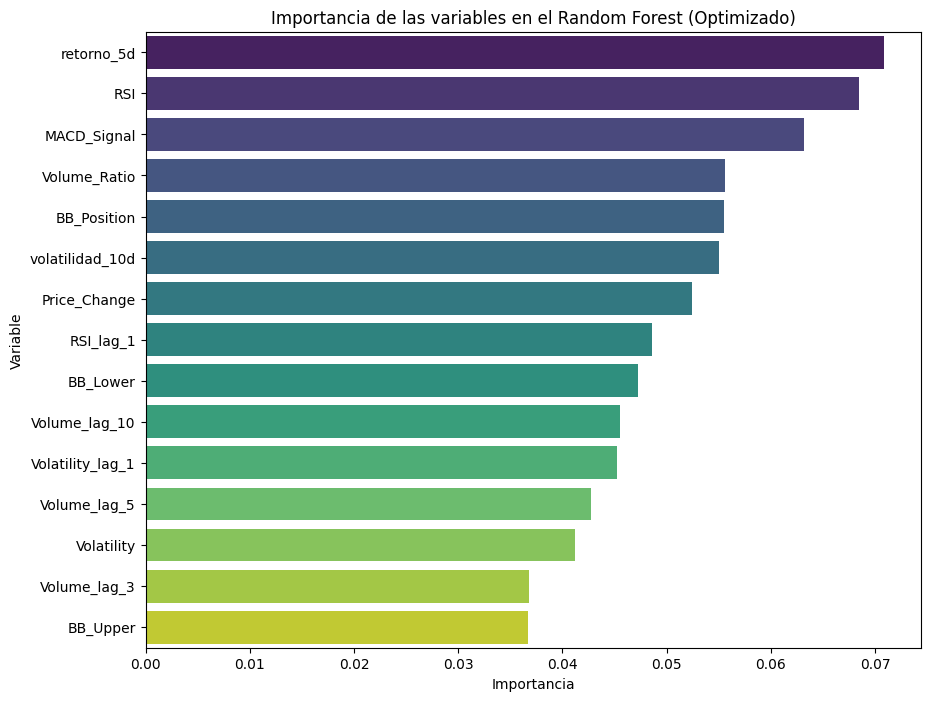

In [ ]:
# Extraer importancia de las variables del mejor modelo
importancias = pd.DataFrame({'Variable': X_train.columns,
                             'Importancia': best_rf.feature_importances_}).sort_values(by='Importancia', ascending=False)

# Top 15 variables más importantes:
importancias.head(15)

In [ ]:
# Graficar las 15 primeras para tener una mejor visión
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancias.head(15), palette='viridis')
plt.title('Importancia de las variables en el Random Forest (Optimizado)')
plt.show()

## ¿Qué buscar en los resultados?
- Caso A: La Precision de la Clase 1 sube o se mantiene (~0.53):
Significado: ¡Excelente! El modelo es capaz de encontrar patrones de mercado sin saber qué acción está mirando. Este es un modelo mucho más robusto para el futuro.

- Caso B: La Precision cae al 0.50:
Significado: Malas noticias. El modelo no sabe leer el RSI ni la Volatilidad de forma útil todavía. Necesitas indicadores más agresivos (como el volumen relativo o la distancia a medias móviles) o datos de mayor calidad.

### Resultado:
Como vemos que la precisión de la clase 1. está en el 53% podemos decir que hemos mejorado el modelo quitando la columna 'Ticker'


## Análisis de lo que esto significa para el proyecto:

1. La 'Prueba del Algodón': Tu modelo es real
Si el modelo hubiera bajado al 50% (puro azar) al quitar el Ticker, sabríamos que el modelo era un 'fraude' que solo memorizaba nombres. Al mantenerse en el 0.52, has demostrado que tus indicadores técnicos (RSI, Volatilidad, etc.) tienen una ventaja estadística real, aunque sea pequeña. El modelo está encontrando patrones en el comportamiento del precio que son universales para cualquier acción.

2. Análisis del Reporte sin Ticker
Precision (0.53): Sigue siendo tu número más importante. De cada 100 señales de 'subida', 53 son correctas. Sin el Ticker, el modelo es igual de 'preciso', lo que lo hace más robusto para usarlo con acciones nuevas que el modelo nunca haya visto.

Recall (0.63): Ha bajado ligeramente (antes era 0.67). Esto significa que al quitarle la 'muleta' del Ticker, el modelo es un poco más conservador, pero sigue capturando la mayoría de las subidas.